# Restricted Boltzmann Machines from Scratch 🔋

## 🔋 Theoretical Background
A Restricted Boltzmann Machine is a generative stochastic artificial neural network that can learn a probability distribution over its set of inputs.
- **Energy-Based Model**: $P(v, h) = \frac{e^{-E(v, h)}}{Z}$.
- **Contrastive Divergence (CD-k)**: An efficient algorithm for approximating the gradient of the log-likelihood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

class RBM:
    def __init__(self, n_visible, n_hidden):
        self.W = np.random.randn(n_visible, n_hidden) * 0.1
        self.v_bias = np.zeros(n_visible)
        self.h_bias = np.zeros(n_hidden)
        
    def _sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))
        
    def sample_h(self, v):
        prob_h = self._sigmoid(v @ self.W + self.h_bias)
        return prob_h, (prob_h > np.random.rand(*prob_h.shape)).astype(float)
        
    def sample_v(self, h):
        prob_v = self._sigmoid(h @ self.W.T + self.v_bias)
        return prob_v, (prob_v > np.random.rand(*prob_v.shape)).astype(float)
        
    def train(self, data, lr=0.1, epochs=100):
        for epoch in range(epochs):
            # CD-1
            v0 = data
            ph0, h0 = self.sample_h(v0)
            pv1, v1 = self.sample_v(h0)
            ph1, h1 = self.sample_h(v1)
            
            # Update weights and biases
            self.W += lr * (v0.T @ ph0 - v1.T @ ph1) / data.shape[0]
            self.v_bias += lr * np.mean(v0 - v1, axis=0)
            self.h_bias += lr * np.mean(ph0 - ph1, axis=0)

# Dummy binary data (e.g., 4x4 patterns)
data = np.array([
    [1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0]
])

rbm = RBM(n_visible=16, n_hidden=4)
rbm.train(data, epochs=500)


### 📊 Visualization: Learned Weights

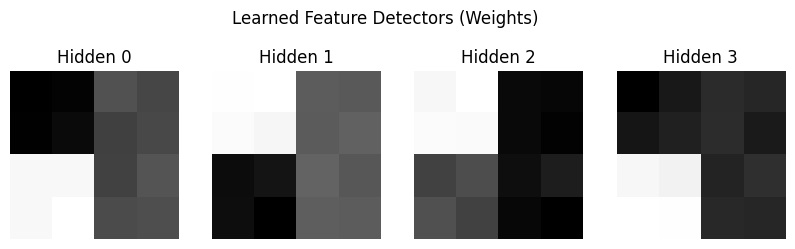

In [3]:

plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(rbm.W[:, i].reshape(4, 4), cmap='gray')
    plt.title(f'Hidden {i}')
    plt.axis('off')
plt.suptitle('Learned Feature Detectors (Weights)')
plt.show()
